# 🤖 BigMart Sales Prediction — Model Building
**Notebook 02 | Preprocessing → Feature Engineering → Training → Evaluation → Export**

Pipeline:
1. Load & Clean Data
2. Feature Engineering
3. Encoding & Scaling
4. Train/Validation Split
5. Baseline Model
6. Multiple Model Comparison
7. Hyperparameter Tuning (XGBoost)
8. Feature Importance
9. Save Final Model

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost available ✅')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — pip install xgboost')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded ✅')

XGBoost available ✅
Libraries loaded ✅


## 1️⃣  Load & Clean Data

In [2]:
df = pd.read_csv('../data/Train.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [3]:
# ── Fix Item_Fat_Content labels ───────────────────────────────────────────
fat_map = {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)
print(df['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [4]:
# ── Impute Item_Weight — median per Item_Type ─────────────────────────────
df['Item_Weight'] = df.groupby('Item_Type')['Item_Weight'].transform(
    lambda x: x.fillna(x.median())
)
print(f'Item_Weight nulls remaining: {df["Item_Weight"].isnull().sum()}')

Item_Weight nulls remaining: 0


In [5]:
# ── Impute Outlet_Size — mode per Outlet_Type ─────────────────────────────
outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Small'
)
df['Outlet_Size'] = df.apply(
    lambda row: outlet_size_mode[row['Outlet_Type']]
    if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)
print(f'Outlet_Size nulls remaining: {df["Outlet_Size"].isnull().sum()}')

Outlet_Size nulls remaining: 0


In [6]:
# ── Fix Item_Visibility zeroes (replace with category mean) ───────────────
df['Item_Visibility'] = df.groupby('Item_Type')['Item_Visibility'].transform(
    lambda x: x.replace(0, x[x > 0].mean())
)
print(f'Zero visibility remaining: {(df["Item_Visibility"] == 0).sum()}')

Zero visibility remaining: 0


## 2️⃣  Feature Engineering

In [7]:
# ── Outlet Age ────────────────────────────────────────────────────────────
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']   # data collected ~2013

# ── Item_Category from Item_Identifier prefix ──────────────────────────────
df['Item_Category'] = df['Item_Identifier'].str[:2]
df['Item_Category'] = df['Item_Category'].map({'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'})

# ── Non-consumable items can't have fat content → recode ──────────────────
df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

# ── Price per unit weight ──────────────────────────────────────────────────
df['Price_per_Weight'] = df['Item_MRP'] / df['Item_Weight']

# ── Visibility Rank within outlet ─────────────────────────────────────────
df['Visibility_MeanRatio'] = df['Item_Visibility'] / df.groupby('Outlet_Identifier')['Item_Visibility'].transform('mean')

print('Feature engineering done ✅')
print(df[['Item_Category', 'Outlet_Age', 'Price_per_Weight', 'Visibility_MeanRatio']].head())

Feature engineering done ✅
    Item_Category  Outlet_Age  Price_per_Weight  Visibility_MeanRatio
0            Food          14         26.861204              0.247450
1          Drinks           4          8.153581              0.292125
2            Food          14          8.092457              0.258441
3            Food          15          9.484115              0.701558
4  Non-Consumable          26          6.031512              1.008780


## 3️⃣  Encoding & Scaling

In [8]:
# Drop columns not used in modelling
drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year']
df_model = df.drop(columns=drop_cols)

# ── Label Encode all object columns ───────────────────────────────────────
le = LabelEncoder()
label_encoders = {}
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le   # store for app inference

print('Encoded columns:', cat_cols)
df_model.head(3)

Encoded columns: ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category,Price_per_Weight,Visibility_MeanRatio
0,9.30,0,0.016047,4,249.8092,1,0,1,3735.1380,14,1,26.861204,0.247450
1,5.92,2,0.019278,14,48.2692,1,2,2,443.4228,4,0,8.153581,0.292125
2,17.50,0,0.016760,10,141.6180,1,0,1,2097.2700,14,1,8.092457,0.258441


## 4️⃣  Train / Validation Split

In [9]:
X = df_model.drop(columns=['Item_Outlet_Sales'])
y = df_model['Item_Outlet_Sales']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: (6818, 12) | Val: (1705, 12)


## 5️⃣  Helper: Evaluation Function

In [10]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:35s}  RMSE={rmse:8.2f}  MAE={mae:7.2f}  R²={r2:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []

## 6️⃣  Model Comparison

In [11]:
# ── Linear Models ─────────────────────────────────────────────────────────
for name, model in [
    ('Linear Regression',   LinearRegression()),
    ('Ridge Regression',    Ridge(alpha=1.0)),
    ('Lasso Regression',    Lasso(alpha=0.01)),
]:
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_val_sc)
    results.append(evaluate(name, y_val, preds))

Linear Regression                    RMSE= 1113.45  MAE= 829.87  R²=0.5439
Ridge Regression                     RMSE= 1113.44  MAE= 829.86  R²=0.5439
Lasso Regression                     RMSE= 1113.45  MAE= 829.87  R²=0.5439


In [12]:
# ── Tree-Based Models ─────────────────────────────────────────────────────
for name, model in [
    ('Decision Tree',           DecisionTreeRegressor(random_state=42)),
    ('Random Forest',           RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('Extra Trees',             ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',       GradientBoostingRegressor(n_estimators=200, random_state=42)),
]:
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    results.append(evaluate(name, y_val, preds))

Decision Tree                        RMSE= 1470.77  MAE=1008.19  R²=0.2041
Random Forest                        RMSE= 1075.18  MAE= 755.14  R²=0.5747
Extra Trees                          RMSE= 1110.50  MAE= 777.24  R²=0.5463
Gradient Boosting                    RMSE= 1046.49  MAE= 731.37  R²=0.5971


In [13]:
# ── XGBoost ───────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                  max_depth=6, subsample=0.8,
                                  colsample_bytree=0.8, random_state=42,
                                  verbosity=0)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = xgb_model.predict(X_val)
    results.append(evaluate('XGBoost', y_val, preds))

XGBoost                              RMSE= 1058.39  MAE= 739.31  R²=0.5879


In [14]:
# ── Comparison Table ──────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('RMSE')
print('\n=== Model Leaderboard ===')
print(results_df.to_string(index=False))


=== Model Leaderboard ===
            Model        RMSE         MAE       R2
Gradient Boosting 1046.488548  731.367785 0.597075
          XGBoost 1058.388939  739.308768 0.587859
    Random Forest 1075.176712  755.136534 0.574681
      Extra Trees 1110.495636  777.243996 0.546279
 Ridge Regression 1113.440243  829.864009 0.543869
 Lasso Regression 1113.452663  829.869857 0.543859
Linear Regression 1113.453868  829.870836 0.543858
    Decision Tree 1470.772879 1008.189895 0.204122


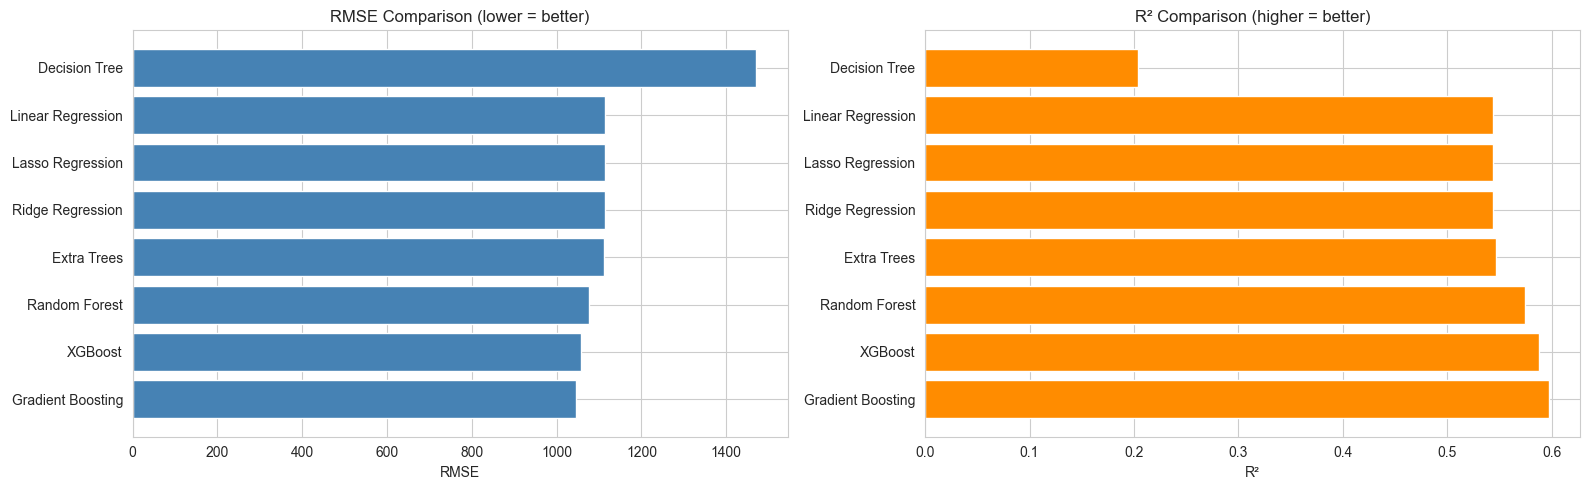

In [15]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

results_df_plot = results_df.sort_values('RMSE', ascending=True)
axes[0].barh(results_df_plot['Model'], results_df_plot['RMSE'], color='steelblue')
axes[0].set_title('RMSE Comparison (lower = better)')
axes[0].set_xlabel('RMSE')

results_df_plot2 = results_df.sort_values('R2', ascending=False)
axes[1].barh(results_df_plot2['Model'], results_df_plot2['R2'], color='darkorange')
axes[1].set_title('R² Comparison (higher = better)')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()

## 7️⃣  Hyperparameter Tuning — XGBoost

In [16]:
if XGB_AVAILABLE:
    param_dist = {
        'n_estimators':      [200, 300, 500],
        'max_depth':         [4, 5, 6, 7],
        'learning_rate':     [0.01, 0.05, 0.1],
        'subsample':         [0.7, 0.8, 0.9],
        'colsample_bytree':  [0.7, 0.8, 0.9],
        'min_child_weight':  [1, 3, 5],
    }
    base_xgb = xgb.XGBRegressor(random_state=42, verbosity=0)
    rscv = RandomizedSearchCV(
        base_xgb, param_dist, n_iter=20, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    rscv.fit(X_train, y_train)
    print('Best params:', rscv.best_params_)

    best_model = rscv.best_estimator_
    tuned_preds = best_model.predict(X_val)
    print('\nTuned XGBoost:')
    results.append(evaluate('XGBoost (Tuned)', y_val, tuned_preds))
else:
    # Fall back to Gradient Boosting as best model
    best_model = GradientBoostingRegressor(n_estimators=300, random_state=42)
    best_model.fit(X_train, y_train)
    print('Using Gradient Boosting as best model.')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Tuned XGBoost:
XGBoost (Tuned)                      RMSE= 1026.54  MAE= 730.66  R²=0.6123


## 8️⃣  Feature Importance

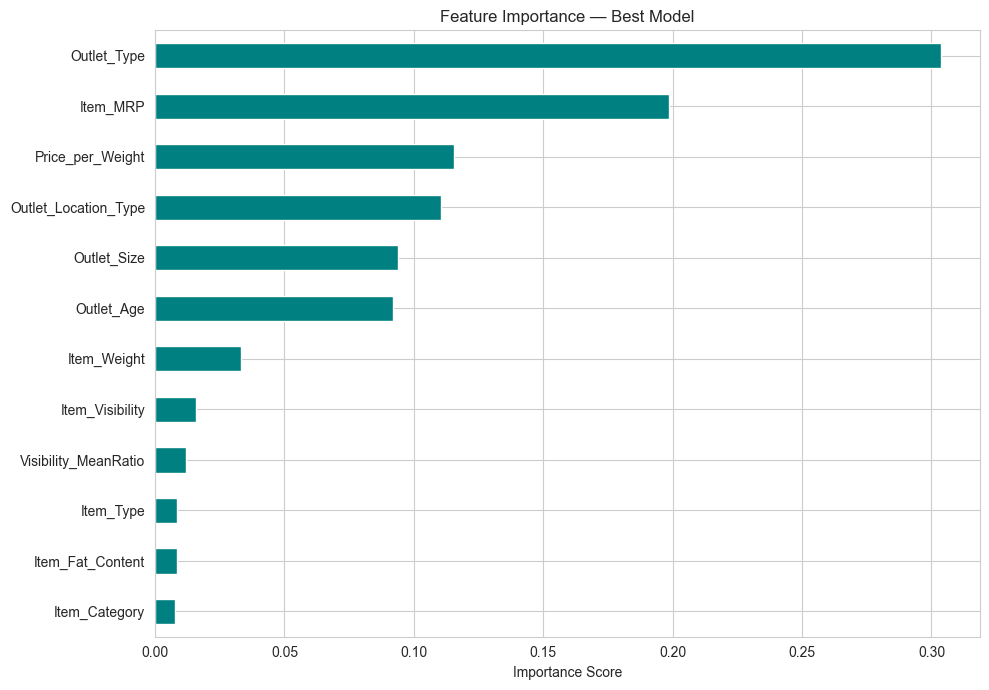

Outlet_Type             0.303572
Item_MRP                0.198590
Price_per_Weight        0.115714
Outlet_Location_Type    0.110480
Outlet_Size             0.093924
Outlet_Age              0.091922
Item_Weight             0.033170
Item_Visibility         0.015955
Visibility_MeanRatio    0.011903
Item_Type               0.008642
Item_Fat_Content        0.008331
Item_Category           0.007796
dtype: float32


In [17]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance — Best Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(feat_imp.sort_values(ascending=False))

## 9️⃣  Residual Analysis

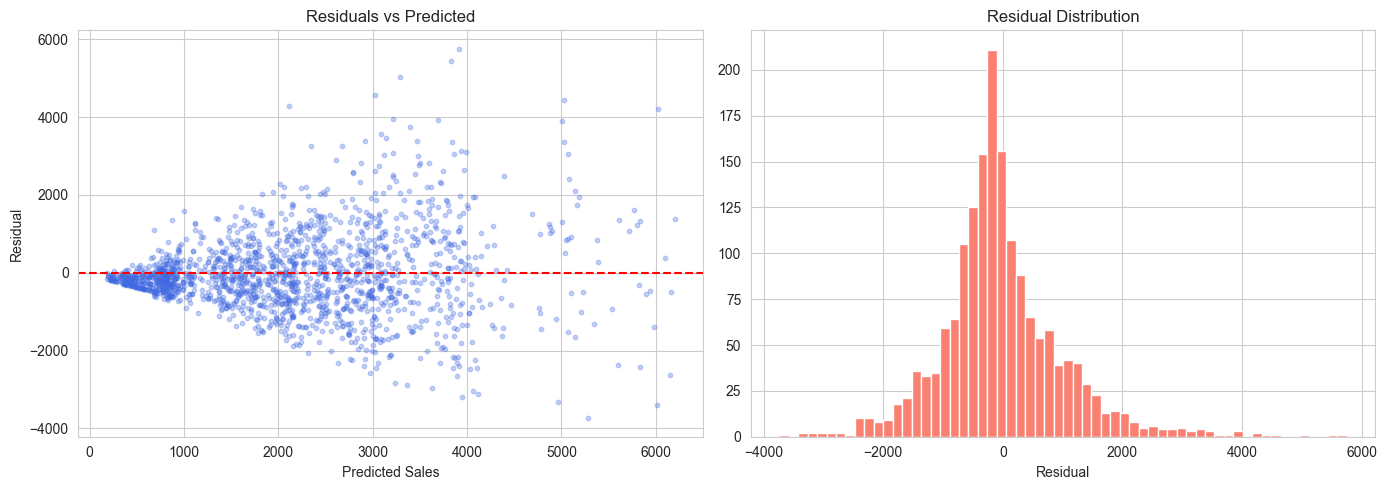

In [18]:
final_preds = best_model.predict(X_val)
residuals   = y_val - final_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(final_preds, residuals, alpha=0.3, color='royalblue', s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 🔟  Save Model & Artifacts

In [19]:
os.makedirs('../models', exist_ok=True)

artifacts = {
    'model':          best_model,
    'scaler':         scaler,
    'label_encoders': label_encoders,
    'feature_cols':   list(X.columns),
    'cat_cols':       cat_cols,
}

with open('../models/sales_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Model saved to ../models/sales_model.pkl ✅')

# Final metrics
print('\n=== Final Model Performance ===')
evaluate('Best Model (Validation)', y_val, final_preds)

Model saved to ../models/sales_model.pkl ✅

=== Final Model Performance ===
Best Model (Validation)              RMSE= 1026.54  MAE= 730.66  R²=0.6123


{'Model': 'Best Model (Validation)',
 'RMSE': np.float64(1026.5444798253989),
 'MAE': 730.6621679502068,
 'R2': 0.6122865435483837}